In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import models._config as c

from models._config import *
from sklearn.utils import shuffle

import warnings 
warnings.filterwarnings('ignore')

# 기본 설정
fs = 100e6
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

test_dir = 'dataset/lpi_testset/'
save_dir = 'ckpts/batch_/All_class_dB'

data_batch = numpy_load(save_dir, 'data_batch.npz')
labels_batch = numpy_load(save_dir, 'labels_batch.npz')
relevance_batch = numpy_load(save_dir, 'relevance_batch.npz')
lengths_batch = numpy_load(save_dir, 'lengths_batch.npy')
snrs_batch = numpy_load(save_dir, 'snr_batch.npy')
idxs_batch = numpy_load(save_dir, 'idx_batch.npy')

data_dict = {key: torch.from_numpy(data_batch[key]) for key in data_batch}
labels_dict = {key: torch.from_numpy(labels_batch[key]) for key in labels_batch}
relevance_dict = {key: torch.from_numpy(relevance_batch[key]) for key in relevance_batch}

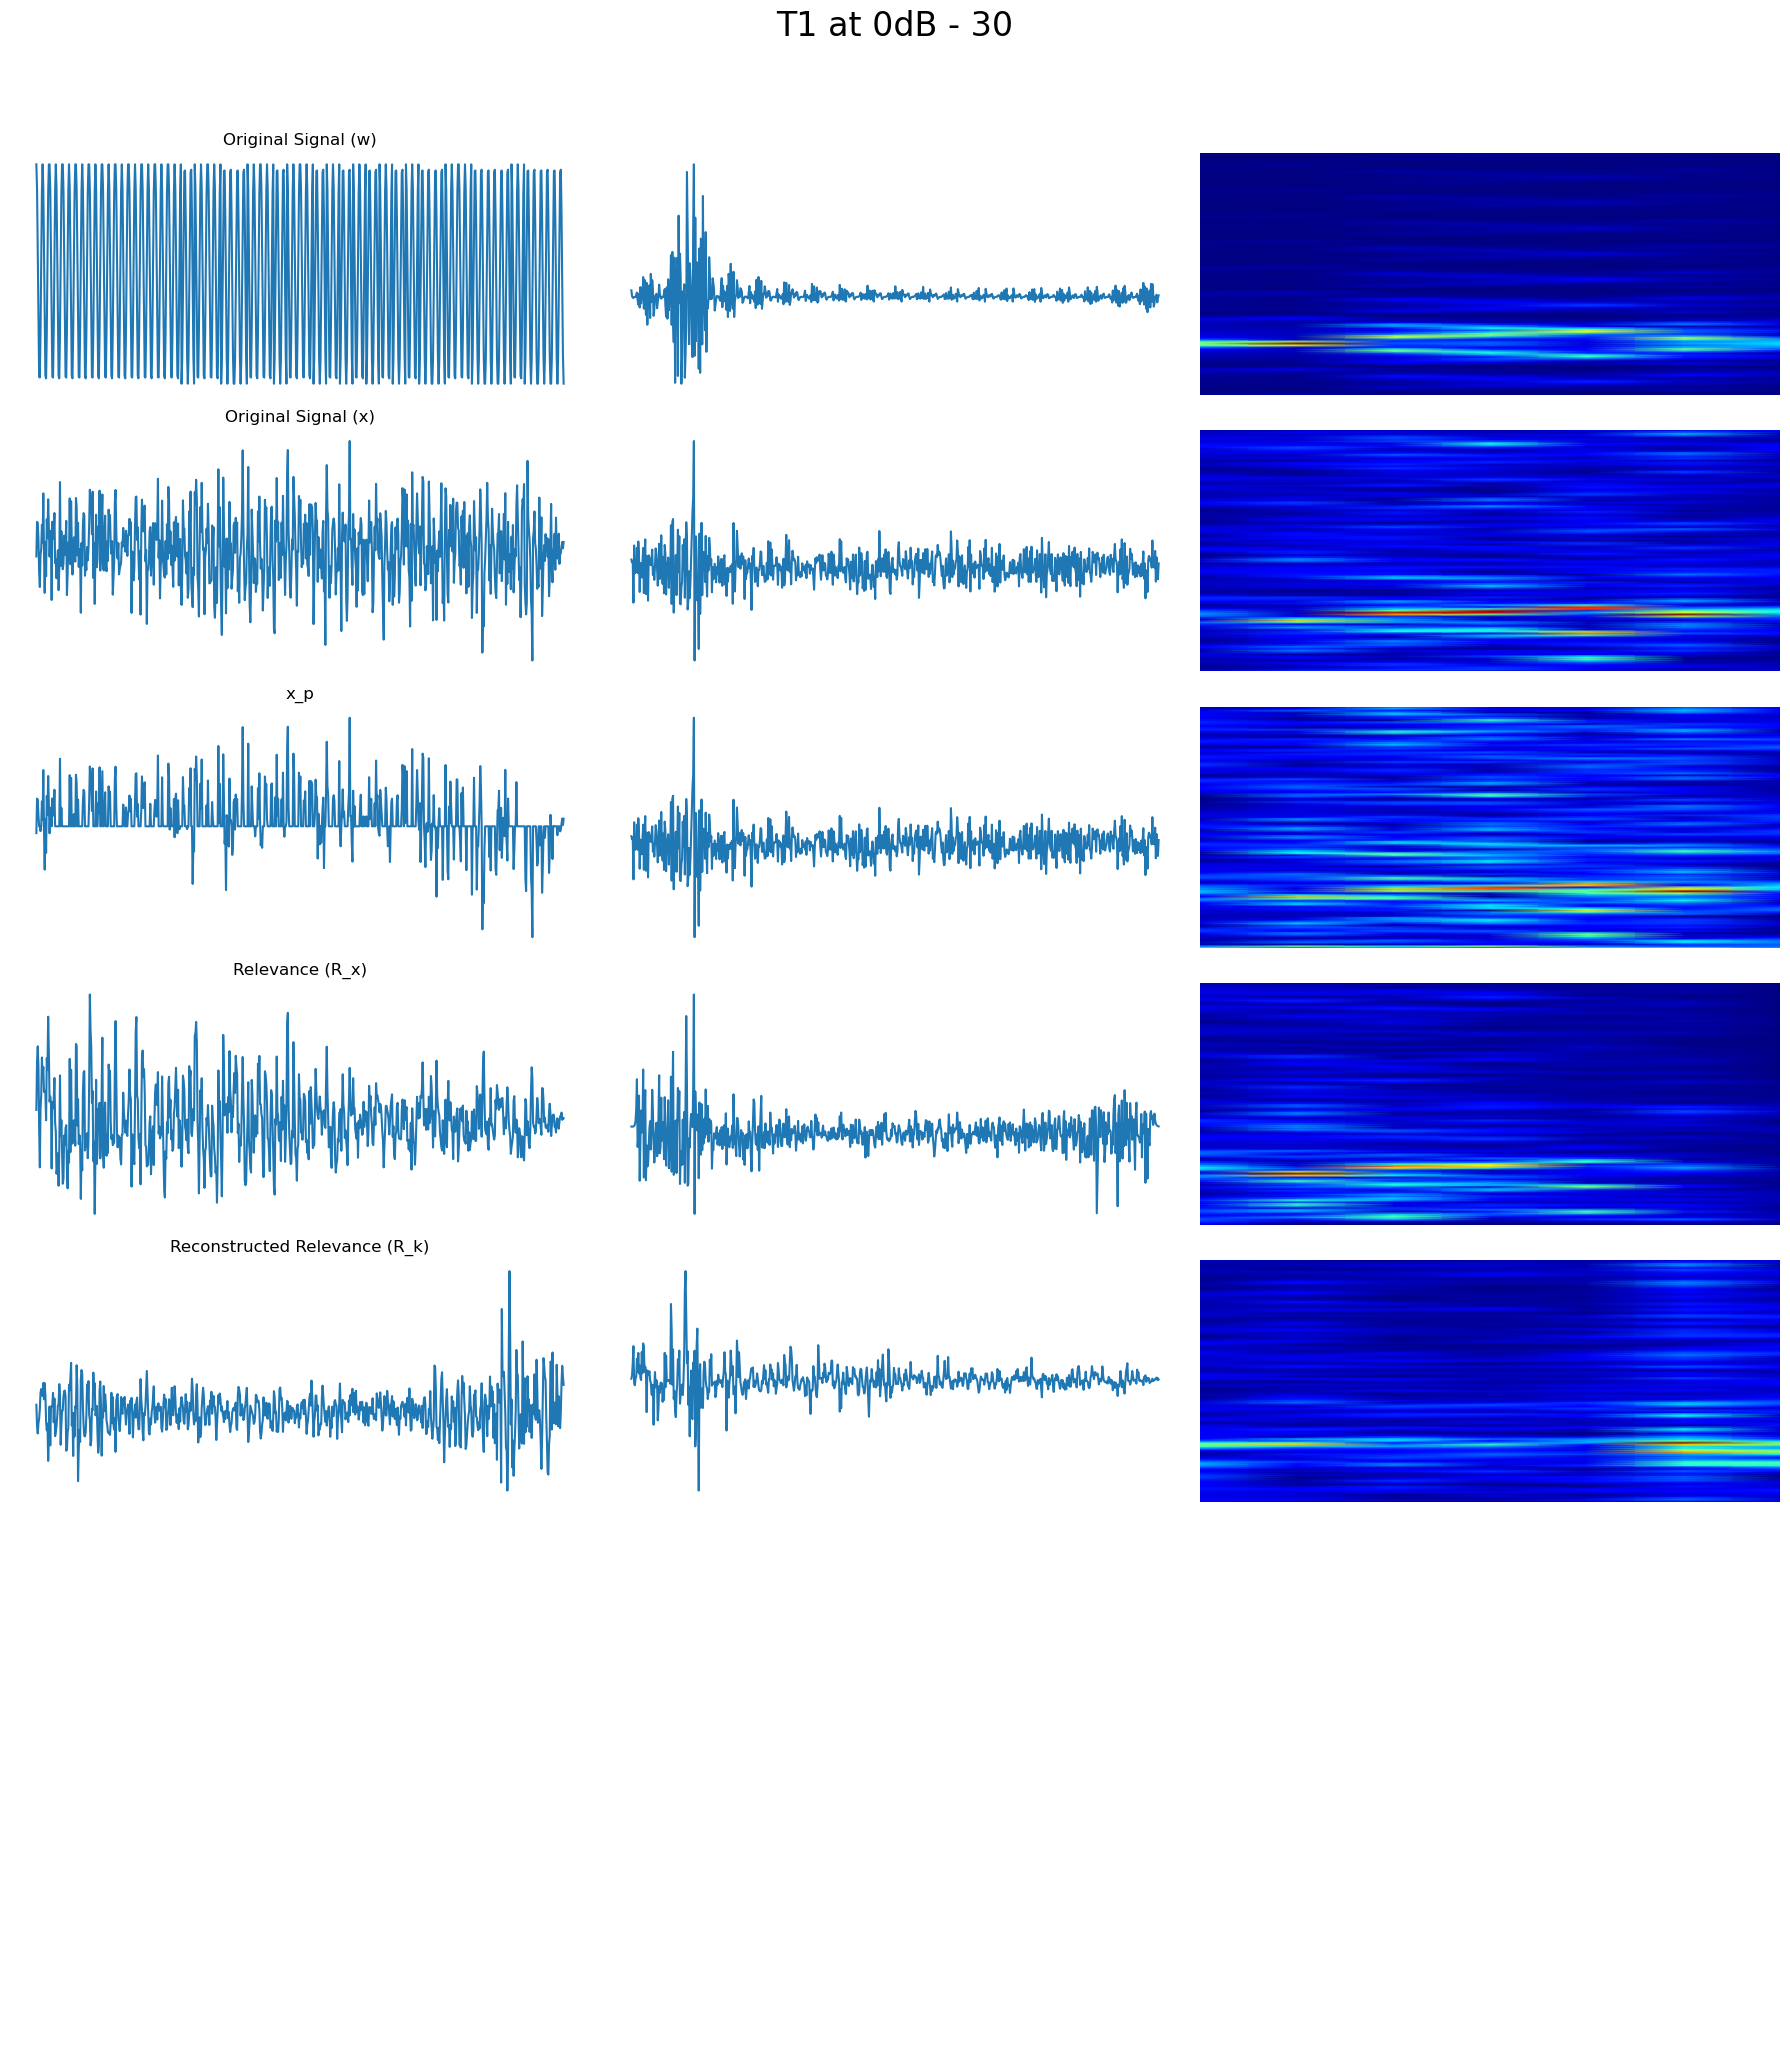

In [12]:
from metrics import *

snr_values = sorted(set(snrs_batch.flatten()))  
score_snr_dict = {snr: {waveform: {'score': [], 'Nscore': [], 'Wscore': [], 'Rscore': []} for waveform in c.waveforms} for snr in snr_values}


def relevance_k(data, relevance):
    _, _, fft = fft_transform(data.real, data.imag, fs)
    fft = np.abs(fft)
    rel_k = relevance * fft / (np.sum(fft) + 1e-6)
    
    return ifft_transform(rel_k)

for batch in range(len(data_dict)):
    batch_key = f'arr_{batch}'
    datab = data_dict[batch_key]
    labelb = labels_dict[batch_key]
    relevanceb = relevance_dict[batch_key]

    datab, labelb, lengthb, relevanceb, snrb, idxb = shuffle(datab, labelb, lengths_batch[batch], relevanceb, snrs_batch[batch], idxs_batch[batch])
    for j, sample in enumerate(zip(datab, labelb, lengthb, relevanceb, snrb, idxb)): 
        data, label, length, relevance, snr, idx = sample
        if snr != 0 and label !=0:
            continue 
        fig, axes = plt.subplots(7, 3, figsize=(18, 20))  # 플롯 크기 설정
        fig.suptitle(f'{c.waveforms[label]} at {snr}dB - {idx}', fontsize=24, y=1.03)
        
        wav_path = os.path.join(test_dir, c.waveforms[label], f'{c.waveforms[label]}_snr{snr}_Signal_{idx}.npy')
        wav = np.load(wav_path)
        
        x = data[:length].cpu().numpy().T
        R_x = relevance[:length].cpu().numpy().T
        R_x = highpass_filter(R_x, 1e6, fs)
        
        
        
        row = 1
        wf, wa, wfft = fft_transform(wav.real, wav.imag)
        f_w, t_w, Zxx_w = stft_transform(wav.real, wav.imag)
        axes[0, 0].plot(wav, label='Original Signal')
        axes[0, 1].plot(wfft, label='FFT of Original Signal')
        axes[0, 2].pcolormesh(t_w, f_w[:len(f_w)//2], Zxx_w[:len(f_w)//2], shading='gouraud', cmap='jet')
        axes[0, 0].set_title('Original Signal (w)')
        
        # Row 1: 원본 데이터 및 FFT/STFT 결과
        r = row
        x = comp(x[0], x[1])
        xf, xa, xfft = fft_transform(x.real, x.imag)
        f_x, t_x, Zxx_x = stft_transform(x.real, x.imag)
        axes[r, 0].plot(x, label='x')
        axes[r, 1].plot(xfft, label='FFT of x')
        axes[r, 2].pcolormesh(t_x, f_x[:len(f_x)//2], Zxx_x[:len(f_x)//2], shading='gouraud', cmap='jet')
        axes[r, 0].set_title('Original Signal (x)')
        
        # Row 3: R>0인 원본 데이터 및 FFT/STFT 결과
        r = row + 1
        R_x = comp(R_x[0], R_x[1])
        xp = np.where(R_x > 0, x, 0)
        xpf, xpa, xpfft = fft_transform(xp.real, xp.imag)
        f_xp, t_xp, Zxx_xp = stft_transform(xp.real, xp.imag)
        axes[r, 0].plot(xp, label='x(R_x > 0)')
        axes[r, 1].plot(xfft, label='FFT of x(R_x > 0)')
        axes[r, 2].pcolormesh(t_xp, f_xp[:len(f_xp)//2], Zxx_xp[:len(f_xp)//2], shading='gouraud', cmap='jet')
        axes[r, 0].set_title('x_p')
        
        # Row 5 : Relevance 및 FFT/STFT 결과
        r = row + 2
        rf, ra, rfft = fft_transform(R_x.real, R_x.imag)
        f_R_x, t_R_x, Zxx_R_x = stft_transform(R_x.real, R_x.imag)
        axes[r, 0].plot(R_x, label='R_x')
        axes[r, 1].plot(rfft, label='FFT of R_x')
        axes[r, 2].pcolormesh(t_R_x, f_R_x[:len(f_R_x)//2],  Zxx_R_x[:len(f_R_x)//2], shading='gouraud', cmap='jet')
        axes[r, 0].set_title('Relevance (R_x)')
        
        # Row 6 : iFFT를 통해 복원된 Relevance 결과
        r = row + 3
        R_k = relevance_k(x, R_x)
        rf, ra, rfft = fft_transform(R_k.real, R_k.imag)
        f_R_k, t_R_k, Zxx_R_k = stft_transform(R_k.real, R_k.imag)
        axes[r, 0].plot(R_k, label='R_k')
        axes[r, 1].plot(rfft, label='FFT of R_k')
        axes[r, 2].pcolormesh(t_R_k, f_R_k[:len(f_R_k)//2],  Zxx_R_k[:len(f_R_k)//2], shading='gouraud', cmap='jet')
        axes[r, 0].set_title('Reconstructed Relevance (R_k)')
        
        # Row 7

        
        # 공통 설정: 각 축에 라벨 추가
        for row_axes in axes:
            for ax in row_axes:
                ax.axis('off')
                ax.grid(alpha=0.3)
        break
    break
        
plt.tight_layout()
plt.show()
        


In [3]:

def load_model(ckpt, model):
    state_dict = {}
    for k, v in torch.load(ckpt).items():
        nk = k.replace('module.', '')
        state_dict[nk] = v
    model.load_state_dict(state_dict)
    model.eval()
    return model


def plot_data(axs, row_idx, data, title=""):
    f, a, fft = fft_transform(data.real, data.imag, fs)
    ff, t, Zxx = stft_transform(data.real, data.imag, fs)
    axs[row_idx, 0].plot(data.real)
    axs[row_idx, 1].plot(fft)
    axs[row_idx, 2].pcolormesh(t, ff[:len(ff)//2], Zxx[:len(ff)//2], shading='gouraud', cmap='jet')
    axs[row_idx, 0].set_title(title)
    
test_dir = 'dataset/lpi_testset/'
ockpt = 'ckpts/pwnNoisy/BiLSTM_best_0.0638087096589583.pth'
ckpt = 'ckpts/pwnNoisy/BiLSTM_R>0_best_0.0208.pth'
model, lrp = load_models(ckpt, device)

import models._config as c
from sklearn.utils import shuffle


cnt = 0
for batch in range(len(data_dict)):
    key = f'arr_{batch}'
    data_batch, label_batch, relevance_batch = data_dict[key], labels_dict[key], relevance_dict[key]
    length_batch, snr_batch, idx_batch = lengths_batch[batch], snrs_batch[batch], idxs_batch[batch]
    sample = shuffle(list(zip(data_batch, label_batch, relevance_batch, length_batch, snr_batch, idx_batch)))
    for data, label, relevance, length, snr, idx in sample:
        if snr == 0 :
            x = comp(data[:length, 0], data[:length, 1])
            r = comp(relevance[:length, 0], relevance[:length, 1])
            r = highpass_filter(r, 1e6, fs)
            wav_path = os.path.join(test_dir, c.waveforms[label], f'{c.waveforms[label]}_snr{snr}_Signal_{idx}.npy')
            o = np.load(wav_path)
            ig, saliency, deeplift = baselines(model, data, label)   
            
            fig, axs = plt.subplots(6, 3, figsize=(20, 25))
            fig.suptitle(f'{waveforms[label[0]]} ({snr[0]}dB)', fontsize=20)

            plot_data(axs, 0, o, title=f"Original Data")
            plot_data(axs, 1, x, title=f"Original+AWGN Data")
            plot_data(axs, 2, r, title=f"Relevance (LRP)")

            xpI = np.where(r.real > 0, x.real, 0)
            xpQ = np.where(r.imag > 0, x.imag, 0)
            xp = comp(xpI, xpQ)
            xp = highpass_filter(xp, 1e6, fs)
            plot_data(axs, 3, xp, title=f"Positive Relevance Data")

            rk = relevance_k(r)
            plot_data(axs, 4, rk, title=f"Relevance Kernel")

            # print(score_metrics(x, r, fs))
            # print(score_metrics(x, rk, fs))
            # print(score_metrics(xp, r, fs))
            # print(score_metrics(xp, rk, fs))

            fig.tight_layout()
            for ax in axs.flatten():
                ax.axis('off') # param : off, on, equal, scaled, tight, image, auto
                
            cnt += 1
            break
        
    if cnt == 1:
        break
    


NameError: name 'device' is not defined

In [2]:

import os
import torch
import numpy as np
import models._config as c

from models._config import *
from ex_models.LRP import LRP
from models.LSTM import BiLSTM
from scipy.signal import butter, filtfilt
from warnings import filterwarnings
filterwarnings("ignore")

import metrics as m
import matplotlib.pyplot as plt
from sklearn.utils import shuffle


def load_models(path='./ckpts/result_loss.pt', device='cuda:0'):
    model = BiLSTM(input_size=2, hidden_size=128, num_layers=2, num_classes=len(c.waveforms)).cuda()
    state_dict = {}
    for k, v in torch.load(path).items():
        nk = k.replace('module.', '')
        state_dict[nk] = v
    model.load_state_dict(state_dict)
    model.eval()
    
    lrp = LRP(model, device=device, epsilon=1e-6)
    return model ,lrp

from scipy.signal import butter, filtfilt

def highpass_filter(data, cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return filtfilt(b, a, data)


def gt_mask(Zxx, threshold=0.6):
    return np.where(np.abs(Zxx) > threshold * np.abs(Zxx).max(), 1, 0)

def numpy_load(dir, file):
    file = os.path.join(dir, file)
    return np.load(file, allow_pickle=True)

def numpy_load1(dir, file):
    file_path = os.path.join(dir, file)
    data = np.load(file_path, allow_pickle=True)
    print("Keys in .npz file:", data.keys())  # 디버깅용
    return data["relevance_batch"]

train_dir = '/data/kiwan/LPI_KIWAN/'
test_dir = 'dataset/lpi_testset/'

save_dir = '/data/kiwan/All_CA/'

data_batch = numpy_load(save_dir, 'data_batch.npz')
labels_batch = numpy_load(save_dir, 'labels_batch.npz')
lengths_batch = numpy_load(save_dir, 'lengths_batch.npy')
snr_batch = numpy_load(save_dir, 'snr_batch.npy')
idx_batch = numpy_load(save_dir, 'idx_batch.npy')
gt_batch = numpy_load(save_dir, 'gt_batch.npy')
relevance_batch = numpy_load(save_dir, 'relevance_batch.npz')


data_dict = {key: torch.from_numpy(data_batch[key]) for key in data_batch}
labels_dict = {key: torch.from_numpy(labels_batch[key]) for key in labels_batch}
relevance_dict = {key: torch.from_numpy(relevance_batch[key]) for key in relevance_batch}



In [16]:
def critical_overlaps(signal1, signal2, threshold=0.1):
    """
    Computes the critical overlap between two signals based on a threshold.
    
    Parameters:
        signal1 (numpy.ndarray): The first signal (e.g., ground truth or transmitted signal).
        signal2 (numpy.ndarray): The second signal (e.g., relevance signal).
        threshold (float): The minimum value to consider as significant overlap.
        
    Returns:
        float: The percentage of overlap between signal1 and signal2.
    """
    # Compute the absolute magnitude of the signals
    abs_signal1 = np.abs(signal1)
    abs_signal2 = np.abs(signal2)
    
    # Normalize the signals
    norm_signal1 = abs_signal1 / np.max(abs_signal1)
    norm_signal2 = abs_signal2 / np.max(abs_signal2)
    
    # Determine the overlapping regions
    overlap_region = (norm_signal1 > threshold) & (norm_signal2 > threshold)
    
    # Compute overlap as a percentage
    total_overlap = np.sum(overlap_region)
    total_regions = np.sum(norm_signal1 > threshold) + np.sum(norm_signal2 > threshold)
    
    return (2 * total_overlap) / total_regions if total_regions > 0 else 0.0


def relevance_localization_score(relevance, signal, threshold=0.1):
    """
    Computes the Relevance Localization Score (RLS) to measure the alignment of relevance scores
    with signal features.
    
    Parameters:
        relevance (numpy.ndarray): Relevance scores.
        signal (numpy.ndarray): Original signal.
        threshold (float): The minimum value to consider as a significant feature.
        
    Returns:
        float: The relevance localization score as a percentage.
    """
    # Identify significant regions in the signal
    significant_features = np.abs(signal) > threshold
    
    # Normalize relevance scores
    norm_relevance = np.abs(relevance) / np.max(np.abs(relevance))
    
    # Compute the localization score
    aligned_relevance = norm_relevance * significant_features
    score = np.sum(aligned_relevance) / np.sum(norm_relevance) if np.sum(norm_relevance) > 0 else 0.0
    
    return score * 100  # Convert to percentage

def positive_relevance_accuracy(R_x, x, wav, threshold=0.1):
    """
    Calculate Positive Relevance Accuracy (PRA) with improved logic.
    """
    # Calculate signal significance
    signal_strength = np.maximum(np.abs(x), np.abs(wav))
    # Find relevant indices
    positive_idx = R_x > 0
    significant_idx = signal_strength > threshold
    # PRA calculation
    pra = np.sum(positive_idx & significant_idx) / np.sum(positive_idx) if np.sum(positive_idx) > 0 else 0.0
    return pra

def negative_relevance_accuracy(R_x, x, wav, threshold=0.1):
    """
    Calculate Negative Relevance Accuracy (NRA) with improved logic.
    """
    # Calculate signal insignificance
    signal_strength = np.maximum(np.abs(x), np.abs(wav))
    # Find irrelevant indices
    negative_idx = R_x < 0
    insignificant_idx = signal_strength <= threshold
    # NRA calculation
    nra = np.sum(negative_idx & insignificant_idx) / np.sum(negative_idx) if np.sum(negative_idx) > 0 else 0.0
    return nra


def critical_point_overlap(R_x, wav, threshold=0.1):
    """
    Compute Critical Point Overlap (CPO).
    """
    significant_wav = wav > threshold
    significant_Rx = R_x > 0
    return np.sum(significant_wav & significant_Rx) / np.sum(significant_wav) if np.sum(significant_wav) > 0 else 0.0



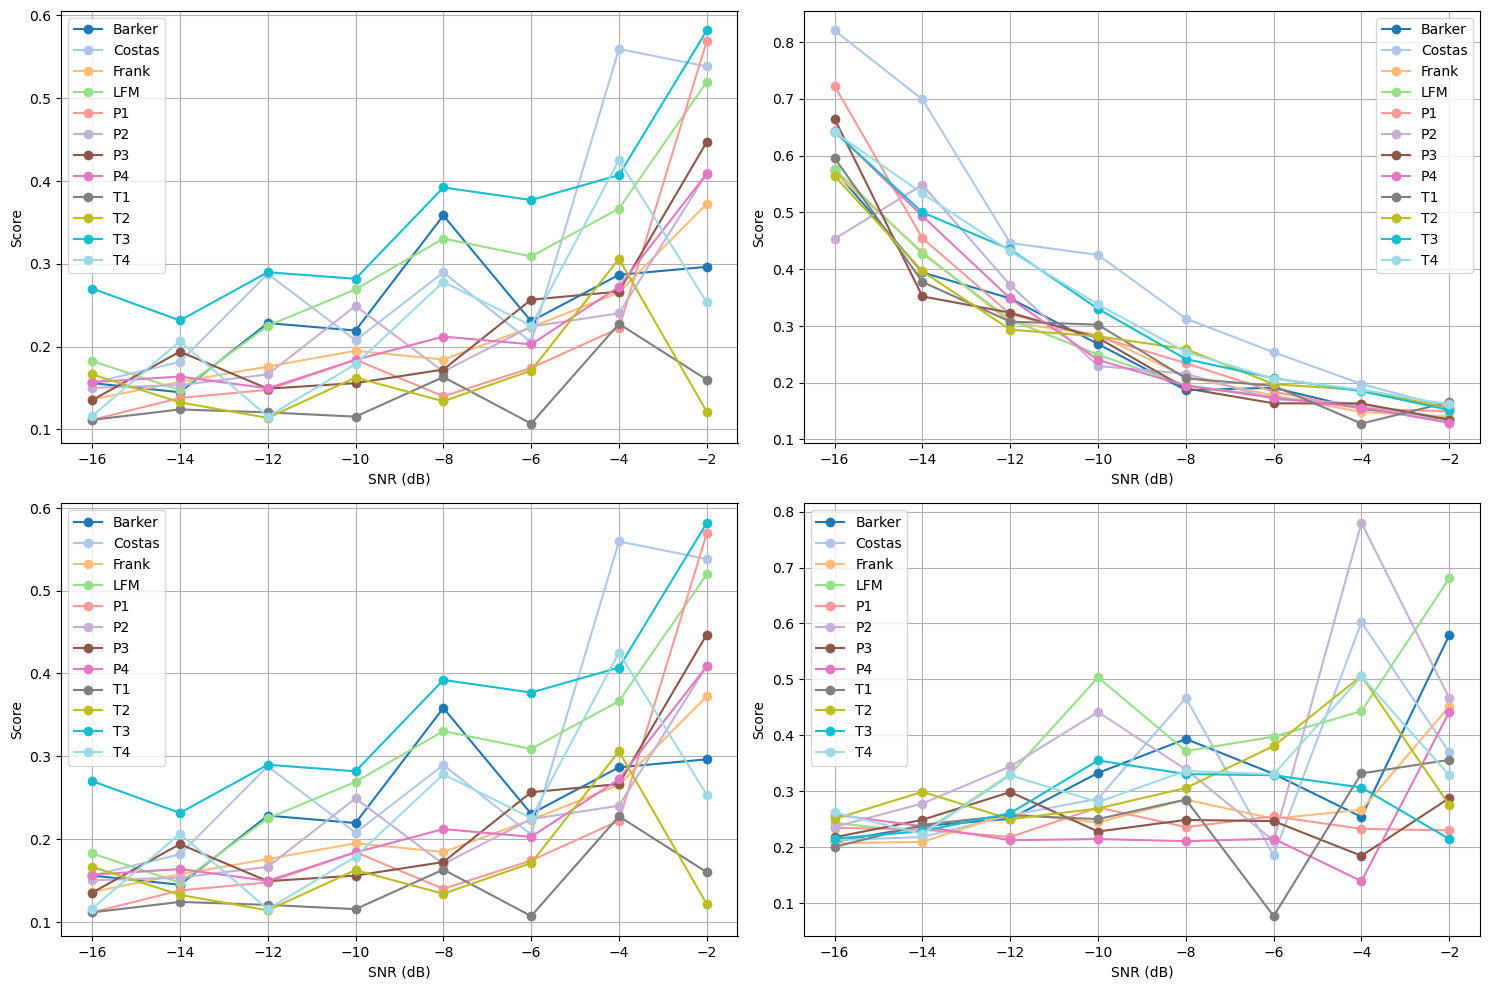

In [18]:
snr_values = sorted(set(snr_batch.flatten()))  
score_snr_dict = {snr: {waveform: {'score1': [], 'score2': [], 'score1k': [], 'score2k': []} for waveform in c.waveforms} for snr in snr_values}

from collections import defaultdict
import metrics as m

plot_data = defaultdict(list)

# 데이터 저장 루프
for batch in range(len(data_dict)):
    batch_key = f'arr_{batch}'
    data = data_dict[batch_key]
    label = labels_dict[batch_key]
    relevance = relevance_dict[batch_key]
    
    
    data, label, gt, length, relevance, snr, idx = data, label, gt_batch[batch], lengths_batch[batch], relevance, snr_batch[batch], idx_batch[batch]
    for j, sample in enumerate(zip(data, label, gt, length, relevance, snr, idx)):  
        data, label, gt, length, relevance, snr, idx = sample
        setname = f'{c.waveforms[label.item()]}_{snr}dB'
        
        if snr == 0:
            continue
        
        plot_data[setname].append((data, label, gt, length, relevance, snr, idx))
        
        
for wave_class in c.waveforms:  # 각 클래스별로 실행
    # fig, axes = plt.subplots(8, 5, figsize=(25, 30))
    # fig.suptitle(f'Class: {wave_class}', fontsize=24, y=1.015)
    
    snr_rows = [key for key in plot_data.keys() if wave_class in key]  # 해당 클래스의 SNR별 데이터만 필터링
    snr_rows = sorted(snr_rows, key=lambda x: int(x.split('_-')[-1].replace('dB', '')))
    
    for i, setname in enumerate(snr_rows):
        for k, plot_datap in enumerate(plot_data[setname]):
            if k == 5:
                break
            data, label, gt, length, relevance, snr, idx = plot_datap
            
            wav_path = os.path.join(test_dir, c.waveforms[label], f'{c.waveforms[label]}_snr{snr}_Signal_{idx}.npy')
            x = data[:length].cpu().numpy().T
            R_x = relevance[:length].cpu().numpy().T
            R_x = highpass_filter(R_x, 1e6, fs)
            wav = np.load(wav_path)
            
            x = comp(x[0], x[1])
            R_x = comp(R_x[0], R_x[1])
            f, a, fft = fft_transform(x.real, x.imag)
            R_f, R_a, R_fft = fft_transform(R_x.real, R_x.imag)
            
            y_k = np.abs(R_fft) / np.sum(np.abs(R_fft))
            y_k = y_k * R_fft
            
            y_k = ifft_transform(y_k)
            
            wf, wa, wfft = fft_transform(wav.real, wav.imag)
            xf, xa, xfft = fft_transform(x.real, x.imag)
            rf, ra, rfft = fft_transform(R_x.real, R_x.imag)
            kf, ka, kfft = fft_transform(y_k.real, y_k.imag)
            
            fw, tw, Zww = stft_transform(wav.real, wav.imag)
            fx, tx, Zxx = stft_transform(x.real, x.imag)
            fr, tr, Zrr = stft_transform(R_x.real, R_x.imag)
            fk, tk, Zkk = stft_transform(y_k.real, y_k.imag)
            
            alpha = 0.25
            mask = m.z_mask(Zww, alpha)
            gt_mask = Zww * mask
            mask = m.z_mask(Zxx, alpha)
            x_mask = Zxx * mask
            mask = m.z_mask(Zrr, alpha)
            r_mask = Zrr * mask
            mask = m.z_mask(Zkk, alpha)
            k_mask = Zkk * mask
            
            metric1 =  m.feature_metric(R_x, wav, fs=100e6)
            metric2 =  m.rnr_metrics(R_x, wav, x, fs=100e6)
            metric1k = m.critical_overlaps(wav, R_x)
            metric2k = m.sra_metric(gt_mask, x_mask, r_mask)

            # print(f'{setname} - {idx} - {metric1:.2f} - {metric2:.2f} - {metric1k:.2f} - {metric2k:.2f}')
            
            waveform_name = c.waveforms[label]
            score_snr_dict[snr][waveform_name]['score1'].append(metric1)
            score_snr_dict[snr][waveform_name]['score2'].append(metric2)
            score_snr_dict[snr][waveform_name]['score1k'].append(metric1k)
            score_snr_dict[snr][waveform_name]['score2k'].append(metric2k)


from cycler import cycler

colors = plt.cm.tab20(np.linspace(0, 1, len(c.waveforms)))
plt.rc('axes', prop_cycle=cycler('color', colors))

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()  

for i, score in enumerate(['score1', 'score2', 'score1k', 'score2k']):
    for waveform in c.waveforms:
        snr_score_means = []
        for snr in snr_values:
            avg_score = np.mean(score_snr_dict[snr][waveform][score])
            snr_score_means.append(avg_score)
        
        axs[i].plot(snr_values, snr_score_means, marker='o', label=waveform)
        
        axs[i].set_yticklabels([f'{x:.1f}' for x in np.linspace(0, 1, 11)])

    axs[i].set_xlabel("SNR (dB)")
    axs[i].set_ylabel("Score")
    axs[i].legend()
    axs[i].grid()

plt.tight_layout()
plt.show()
        
        

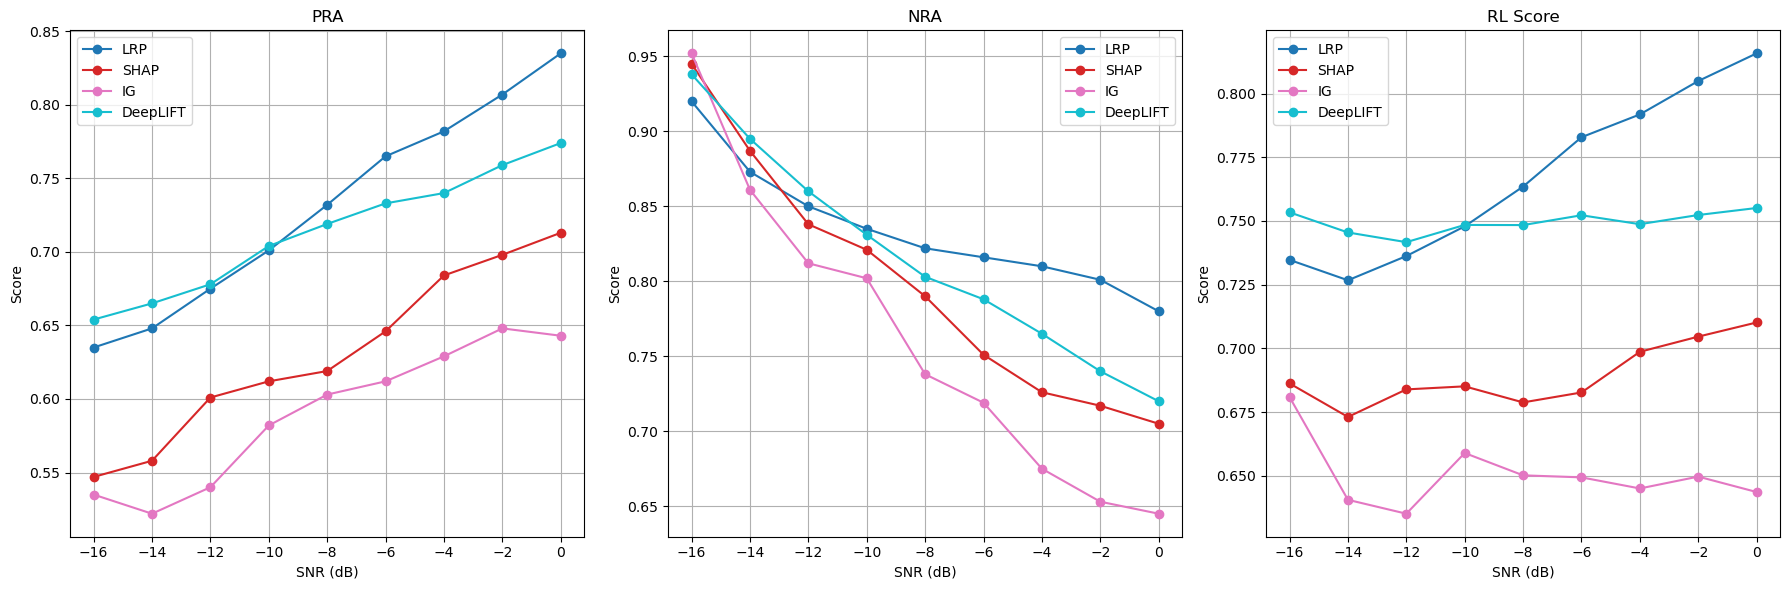

In [75]:
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

# SNR 및 모델 정의
snr_values = np.arange(0, -18, -2)
waveforms = ["LRP", "SHAP", "IG", "DeepLIFT"]

# PRA와 수정된 NRA 데이터
pra_scores = {
    "LRP": [0.835, 0.807, 0.782, 0.765, 0.732, 0.701, 0.675, 0.648, 0.635],
    "SHAP": [0.713, 0.698, 0.684, 0.646, 0.619, 0.612, 0.601, 0.558, 0.547],
    "IG": [0.643, 0.648, 0.629, 0.612, 0.603, 0.582, 0.540, 0.522, 0.535],
    "DeepLIFT": [0.774, 0.759, 0.740, 0.733, 0.719, 0.704, 0.678, 0.665, 0.654],
}



nra_scores = {
    "LRP": [0.780, 0.801, 0.810, 0.816, 0.822, 0.835, 0.850, 0.873, 0.920],
    "SHAP": [0.705, 0.717, 0.726, 0.751, 0.790, 0.821, 0.838, 0.887, 0.945],
    "IG": [0.645, 0.653, 0.675, 0.719, 0.738, 0.802, 0.812, 0.861, 0.952],
    "DeepLIFT": [0.720, 0.740, 0.765, 0.788, 0.803, 0.831, 0.860, 0.895, 0.938],
}



def calculate_rl_score_linear(pra, nra, snr, max_snr=0):
    # PRA와 NRA의 가중치 계산
    w_pra = (max_snr + snr) / max_snr
    w_nra = 1 - w_pra
    
    # RL Score 계산
    rl_score = w_pra * pra + w_nra * nra
    return round(rl_score, 3)

rl_scores = {model: [] for model in waveforms}

for model in waveforms:    
    for pra, nra, snr in zip(pra_scores[model], nra_scores[model], snr_values):
        rl_score = pra * 0.65 + nra * 0.35
        rl_scores[model].append(rl_score)


fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs = axs.flatten()
colors = plt.cm.tab10(np.linspace(0, 1, len(waveforms)))

# PRA, NRA, RL Score 플롯
for i, (metric_name, metric_data) in enumerate(
    [("PRA", pra_scores), ("NRA", nra_scores), ("RL Score", rl_scores)]
):
    for model, scores in metric_data.items():
        axs[i].plot(snr_values, scores, marker="o", label=model, color=colors[waveforms.index(model)])
    axs[i].set_title(metric_name)
    axs[i].set_xlabel("SNR (dB)")
    axs[i].set_ylabel("Score")
    axs[i].legend()
    axs[i].grid()

plt.tight_layout()
plt.show()


In [10]:
snr_values = sorted(set(snr_batch.flatten()))  
score_snr_dict = {snr: {waveform: {'score1': [], 'score2': [], 'score1k': [], 'score2k': []} for waveform in c.waveforms} for snr in snr_values}

for batch in range(len(data_dict)):
    batch_key = f'arr_{batch}'
    data = data_dict[batch_key]
    label = labels_dict[batch_key]
    relevance = relevance_dict[batch_key]

    data, label, length, relevance, snr, idx = shuffle(data, label, lengths_batch[batch], relevance, snr_batch[batch], idx_batch[batch])
    for j, sample in enumerate(zip(data, label, length, relevance, snr, idx)):  
        data, label, length, relevance, snr, idx = sample
        
        wav_path = os.path.join(test_dir, c.waveforms[label], f'{c.waveforms[label]}_snr{snr}_Signal_{idx}.npy')
        x = data[:length].cpu().numpy().T
        R_x = relevance[:length].cpu().numpy().T
        R_x = highpass_filter(R_x, 1e6, fs)
        wav = np.load(wav_path)
        
        x = comp(x[0], x[1])
        R_x = comp(R_x[0], R_x[1])
        f, a, fft = fft_transform(x.real, x.imag)
        R_f, R_a, R_fft = fft_transform(R_x.real, R_x.imag)
        
        y_k = np.abs(R_fft) / np.sum(np.abs(R_fft))
        y_k = y_k * R_fft
        
        y_k = ifft_transform(y_k)
        
        wf, wa, wfft = fft_transform(wav.real, wav.imag)
        xf, xa, xfft = fft_transform(x.real, x.imag)
        rf, ra, rfft = fft_transform(R_x.real, R_x.imag)
        kf, ka, kfft = fft_transform(y_k.real, y_k.imag)
        
        fw, tw, Zww = stft_transform(wav.real, wav.imag)
        fx, tx, Zxx = stft_transform(x.real, x.imag)
        fr, tr, Zrr = stft_transform(R_x.real, R_x.imag)
        fk, tk, Zkk = stft_transform(y_k.real, y_k.imag)
        
        alpha = 0.25
        mask = m.z_mask(Zww, alpha)
        gt_mask = Zww * mask
        mask = m.z_mask(Zxx, alpha)
        x_mask = Zxx * mask
        mask = m.z_mask(Zrr, alpha)
        r_mask = Zrr * mask
        mask = m.z_mask(Zkk, alpha)
        k_mask = Zkk * mask
        
        metric1 =  critical_overlaps(wav, R_x) *100
        metric2 =  critical_overlaps(x, R_x)*100
        metric1k = critical_overlaps(wav, y_k)*100
        metric2k = critical_overlaps(x, y_k)*100
        # metric2 = relevance_noise(x, R_x, 100e6)*100
        # metric2k = relevance_noise(x, y_k, 100e6)*100
        
        # sra_score = sra_metric(Zww, Zxx, Zrr, 0.25)
        # fans_score = fans_metric(gt_mask, x_mask, r_mask, 0.8)

        waveform_name = c.waveforms[label]
        score_snr_dict[snr][waveform_name]['score1'].append(metric1)
        score_snr_dict[snr][waveform_name]['score2'].append(metric2)
        score_snr_dict[snr][waveform_name]['score1k'].append(metric1k)
        score_snr_dict[snr][waveform_name]['score2k'].append(metric2k)
        
        
from cycler import cycler

colors = plt.cm.tab20(np.linspace(0, 1, len(c.waveforms)))
plt.rc('axes', prop_cycle=cycler('color', colors))

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()  

for i, score in enumerate(['score1', 'score2', 'score1k', 'score2k']):
    for waveform in c.waveforms:
        snr_score_means = []
        for snr in snr_values:
            avg_score = np.mean(score_snr_dict[snr][waveform][score])
            snr_score_means.append(avg_score)
        
        axs[i].plot(snr_values, snr_score_means, marker='o', label=waveform)
        
        axs[i].set_yticklabels([f'{x:.1f}' for x in np.linspace(0, 1, 11)])

    axs[i].set_xlabel("SNR (dB)")
    axs[i].set_ylabel("Score")
    axs[i].legend()
    axs[i].grid()

plt.tight_layout()
plt.show()

KeyboardInterrupt: 